# Quantum Mechanical Pendulum Clock

Here we benchmark the approximations used in the main text for parameters that allow for using a smaller Hilbert space dimension. As a first simplification, we go into a rotating frame $\hat{U}(t)\hat{\rho}\hat{U}^\dagger(t)$ with
$$\hat{U}(t) = e^{it(\Omega_{\rm f}\hat{a}^\dagger\hat{a}+\varepsilon_1\hat{p}_1+(\varepsilon_1+\Omega_f)\hat{p}_2+\varepsilon_3\hat{p}_3)}.$$
This results in the same master equation as in Eq.~(3) in the manuscript, but with the Hamiltonian
$$\hat{H} = \Omega_{\rm m}\hat{b}^\dagger\hat{b}+\Delta\hat{p}_2+f(\hat{a}^\dagger\hat{\sigma}+\hat{a}\hat{\sigma}^\dagger)-\sqrt{2}g\hat{a}^\dagger\hat{a}\hat{x}_{\rm m}.$$
The dissipators are not affected by the rotation. In the following, we will set $\Delta =  0$.

In [15]:
using QuantumOptics
using CairoMakie
using DifferentialEquations

### Setting up the problem

In [ ]:
# Parameters
Nm = 60;
Nc = 8;

Ω = 1;
γh = 1;
γc = 50;
γm = 0.01;
κ = 3.4;
f = 2.4;
g = 2.6;
nh = 10;


# Temperatures - set nbc = nf = nbm = 0 for Fig. 13 panels (a) - (c), set nbc = 0.0005 for panels (d) - (f)

nbc = 0.0005; # cavity and mechanical temperatures are set equal to the cold temperature

ω13 = 2*120
ω23 = 1*120
Ωf = ω13-ω23

Tc = ω23/log((nbc+1)/nbc)
nf = 1/(exp(Ωf/Tc)-1)
nbm = 1/(exp(Ω/Tc)-1)


Γ = κ + γh*nh+γc*nbc;

tsim = 10;

In [17]:
# Bases
B_mech = FockBasis(Nm);
B_cav = FockBasis(Nc);
B_atom = NLevelBasis(3);
B = B_atom ⊗ B_cav ⊗ B_mech;

# Operators - atom
σ = transition(B_atom,1,2) ⊗ one(B_cav) ⊗ one(B_mech);
σt = dagger(σ);
σ13 = transition(B_atom,1,3) ⊗ one(B_cav) ⊗ one(B_mech);
σ31 = dagger(σ13);
σ23 = transition(B_atom,2,3) ⊗ one(B_cav) ⊗ one(B_mech);
σ32 = dagger(σ23);

p1 = transition(B_atom,1,1) ⊗ one(B_cav) ⊗ one(B_mech);
p2 = transition(B_atom,2,2) ⊗ one(B_cav) ⊗ one(B_mech);
p3 = transition(B_atom,3,3) ⊗ one(B_cav) ⊗ one(B_mech);

# Operators - cavity
a = one(B_atom) ⊗ destroy(B_cav) ⊗ one(B_mech);
at = one(B_atom) ⊗ create(B_cav) ⊗ one(B_mech);
nc = at*a;

# Operators - mechanics
b = one(B_atom) ⊗ one(B_cav) ⊗ destroy(B_mech);
bt = one(B_atom) ⊗ one(B_cav) ⊗ create(B_mech);
xm = (b+dagger(b))/sqrt(2);
pm = 1im*(dagger(b)-b)/sqrt(2);
nm = bt*b;

In [18]:
# Hamiltonian
H = Ω*nm+f*(at*σ+a*σt)-sqrt(2)*g*nc*xm;

# Jump Operators
J = [sqrt(κ*(nf+1))*a, sqrt(κ*nf)*at, sqrt(γm*(nbm+1))*b, sqrt(γm*nbm)*bt, sqrt(γh*(nh+1))*σ13,sqrt(γh*nh)*σ31 ,sqrt(γc*(nbc+1))*σ23,sqrt(γc*nbc)*σ32];

# Initial state
ψ0 = nlevelstate(B_atom,2) ⊗ fockstate(B_cav,0) ⊗ coherentstate(B_mech,4);

# Integration time
T = [0:0.1:tsim;];

### Stochastic master equation - Eq. (B1)

In [19]:
# setting up error?

δt =0.001
Tf = [0:δt:tsim;];

Jc = sqrt(γc*(nbc+1))*σ23;

Js = [sqrt(κ*(nf+1))*a, sqrt(κ*nf)*at, sqrt(γm*(nbm+1))*b, sqrt(γm*nbm)*bt, sqrt(γh*(nh+1))*σ13,sqrt(γh*nh)*σ31,sqrt(γc*nbc)*σ32];

JdJ = dagger.(J).*J;

Hnh = H-1im/2*(sum(JdJ));#+dagger(Jc)*Jc);

ρ0 = tensor(ψ0,dagger(ψ0));

In [20]:
# time evolution
j = 0;
ρ = ρ0;

exp_xm_master_st = [];
exp_pm_master_st = [];

exp_nc_master_st = [];

exp_p1_master_st = [];
exp_p2_master_st = [];
exp_p3_master_st = [];

exp_as_master_st = [];

NJ = [];

tplot = []

for t in Tf
    j+=1;
    pj = γc*(nbc+1)*δt*real(expect(p3,ρ));
    if pj < rand()
        ttout, ρdt = timeevolution.master_nh([0,δt], ρ, Hnh, Js);
        ρ = ρdt[2]/real(tr(ρdt[2]));
    else
        ρ = δt*Jc*ρ*dagger(Jc)/pj;
        push!(NJ,t);
    end
    if isodd(j)
        push!(exp_xm_master_st,real(expect(xm, ρ)))
        push!(exp_pm_master_st,real(expect(pm, ρ)))
        push!(exp_nc_master_st,real(expect(nc, ρ)))
        push!(exp_p1_master_st,real(expect(p1, ρ)))
        push!(exp_p2_master_st,real(expect(p2, ρ)))
        push!(exp_p3_master_st,real(expect(p3, ρ)))
        push!(exp_as_master_st,expect(at*σ, ρ))
        push!(tplot,t)
    end
end

### Stochastic differential equations - Eqs. (39) for M=1

In [21]:
#δt =0.0001
#Tf = [0:δt:tsim;];

u0 = [0.0;0.0;0.0;0.0;1.0;real(expect(xm,ψ0));real(expect(pm,ψ0))]

function semiclass_nojump!(du,u,p,t)
    du[1] = -κ*(u[1]-nf) + 2*f*u[2]
    du[2] = -Γ/2*u[2]-sqrt(2)*g*u[3]*u[6]+f*u[5]+f*u[1]*(u[5]-u[4])+γc*(nbc+1)*u[2]*(1-u[4]-u[5])
    du[3] = -Γ/2*u[3]+sqrt(2)*g*u[2]*u[6]+γc*(nbc+1)*u[3]*(1-u[4]-u[5])
    du[4] = -γh*nh*u[4]+2*f*u[2]+γh*(nh+1)*(1-u[4]-u[5])+γc*(nbc+1)*u[4]*(1-u[4]-u[5])
    du[5] = -γc*nbc*u[5] -2*f*u[2]+γc*(nbc+1)*(1-u[4]-u[5])-γc*(nbc+1)*(1-u[5])*(1-u[4]-u[5])
    du[6] = -γm/2*u[6] + Ω*u[7]
    du[7] = -γm/2*u[7] - Ω*u[6]+sqrt(2)*g*u[1]
end

semiclass_nojump! (generic function with 1 method)

In [22]:
# time evolution, given jump trajectory
j = 0;
u = u0;

utot = [];
t0 = 0;
tar2 = [];

times = cat(NJ,tsim; dims = 1)

for t in times

    tspan = (t0,t-δt)

    prob = ODEProblem(semiclass_nojump!,u,tspan)

    sol = solve(prob,Rosenbrock23(),isoutofdomain = isoutofdomain);
    
    utot = cat(utot, sol.u; dims = 1);
    tar2 = cat(tar2, sol.t; dims=1);

    u = sol.u[end];
    
    u[2] = 0;
    u[3] = 0;
    u[4] = 0;
    u[5] = 1;

    push!(utot, u)
    push!(tar2,t)

    t0 = t+δt

end

LoadError: UndefVarError: `isoutofdomain` not defined in `Main`
Suggestion: check for spelling errors or missing imports.

### Stochastic master equation - Eq. (16)

In [ ]:
# Basis
fNc = 20;
fB =  FockBasis(fNc);

# Operators - atom
fσ = transition(B_atom,1,2) ⊗ one(fB);
fσt = dagger(fσ);
fσ13 = transition(B_atom,1,3) ⊗ one(fB);
fσ31 = dagger(fσ13);
fσ23 = transition(B_atom,2,3) ⊗ one(fB);
fσ32 = dagger(fσ23);

fp1 = transition(B_atom,1,1) ⊗ one(fB);
fp2 = transition(B_atom,2,2) ⊗ one(fB);
fp3 = transition(B_atom,3,3) ⊗ one(fB);

# Operators - cavity
fa = one(B_atom) ⊗ destroy(fB);
fat = one(B_atom) ⊗ create(fB);
fnc = fat*fa;

In [ ]:
# Hamiltonian
function fH(x)
    return f*(fat*fσ+fa*fσt)-sqrt(2)*g*fnc*x;
end

# Jump Operators
fJ = [sqrt(κ*(nf+1))*fa,sqrt(κ*nf)*fat,sqrt(γh*(nh+1))*fσ13,sqrt(γh*nh)*fσ31, sqrt(γc*(nbc+1))*fσ23,sqrt(γc*nbc)*fσ32];

fJdJ = dagger.(fJ).*fJ;

# Initial state
fψ0 = nlevelstate(B_atom,2) ⊗ fockstate(fB,0);
fρ0 = tensor(fψ0,dagger(fψ0));

In [ ]:
# time evolution, given jump trajectory
j = 0;

#δt =0.001;
t0 = 0;

j = 0;
fρ = fρ0;

fxm_st = []
fpm_st = []

fnc_st = [];

fp1_st = [];
fp2_st = [];
fp3_st = [];

fas_st = [];

ftplot_st = []

fρ = fρ0;
fxm = real(expect(xm,ψ0));
fpm = real(expect(pm,ψ0));

fJc = sqrt(γc*(nbc+1))*fσ23;
fJct = dagger(fJc);

fJs = [sqrt(κ*(nf+1))*fa,sqrt(κ*nf)*fat,sqrt(γh*(nh+1))*fσ13,sqrt(γh*nh)*fσ31,sqrt(γc*nbc)*fσ32];

times = cat(NJ,tsim; dims = 1)

for t in times

    Tf2 = [t0:δt:t-δt;]

    for t2 in Tf2
        j += 1
        tdisc, fρ = timeevolution.master_nh([0,δt], fρ, fH(fxm)-1im/2*(sum(fJdJ)), fJs);
        fρ = fρ[end]/tr(fρ[end]);
        exp_fnc = real(expect(fnc, fρ));
    
        fxm += δt*(Ω*fpm-γm/2*fxm);
        fpm += δt*(-Ω*fxm-γm/2*fpm+sqrt(2)*g*exp_fnc);
    
        if isodd(j)
            push!(fxm_st,fxm)
            push!(fpm_st,fpm)
            push!(fnc_st,exp_fnc)
            push!(fp1_st,real(expect(fp1, fρ)))
            push!(fp2_st,real(expect(fp2, fρ)))
            push!(fp3_st,real(expect(fp3, fρ)))
            push!(fas_st,expect(fat*fσ, fρ))
            push!(ftplot_st,t2)
        end
    end

    fρ = fJc*fρ*fJct;
    
    fρ = fρ/tr(fρ);

    j +=1
    t0 = t+δt
end

# Plots

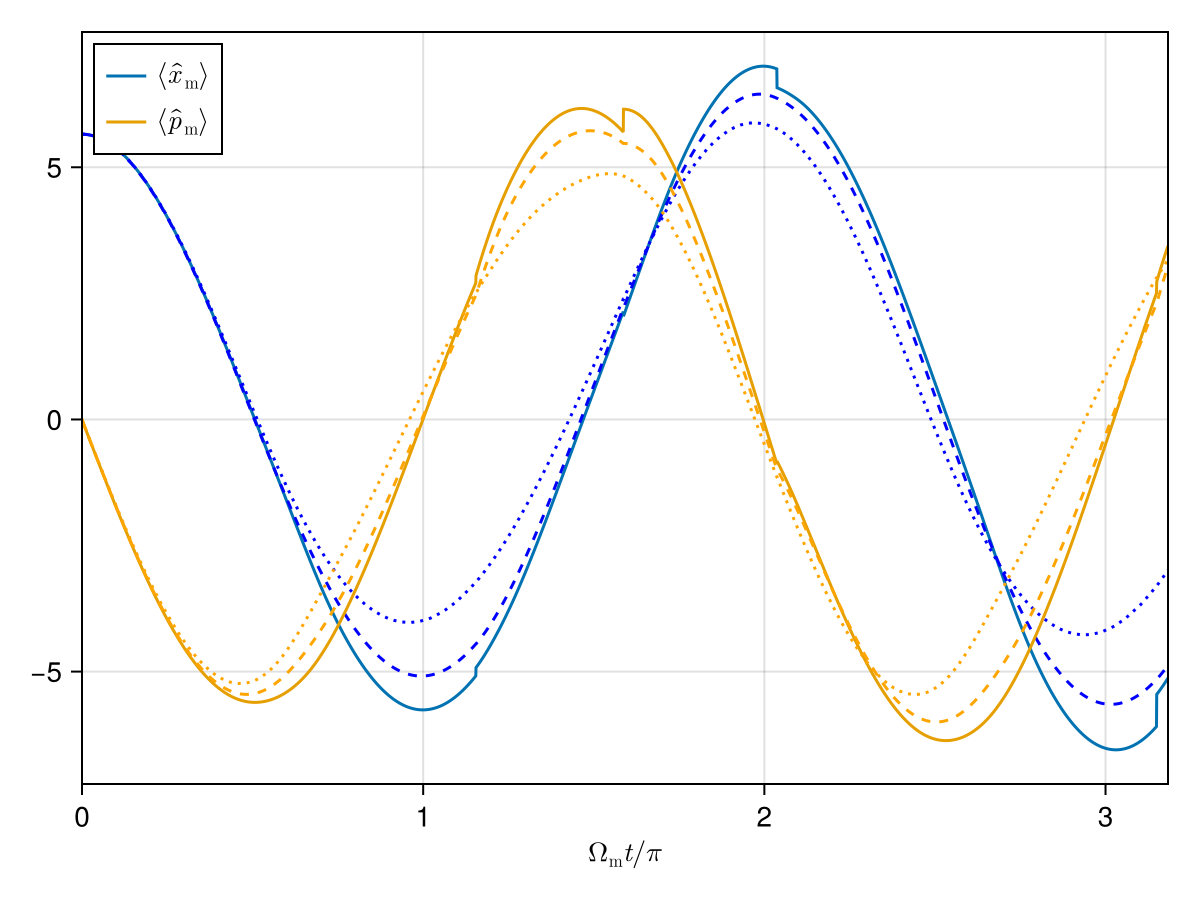

In [ ]:
# figures mechanics stochastics - Fig. 13 panels (a) and (d)
F = Figure()
ax = Axis(F[1,1],xlabel = L"\Omega_\text{m}t/\pi")

lines!(ax,tplot/pi, exp_xm_master_st,label = L"\langle\hat{x}_\text{m}\rangle")
lines!(ax,ftplot_st/pi, fxm_st, color = :blue, linestyle = :dash)
lines!(ax,tar2/pi, getindex.(utot,6), color = :blue, linestyle = :dot)
lines!(ax,tplot/pi, exp_pm_master_st,label = L"\langle\hat{p}_\text{m}\rangle")
lines!(ax,ftplot_st/pi, fpm_st, color = :orange, linestyle = :dash)
lines!(ax,tar2/pi, getindex.(utot,7), color = :orange, linestyle = :dot)
axislegend(position = :lt)
xlims!(ax,0,tsim/pi)

F

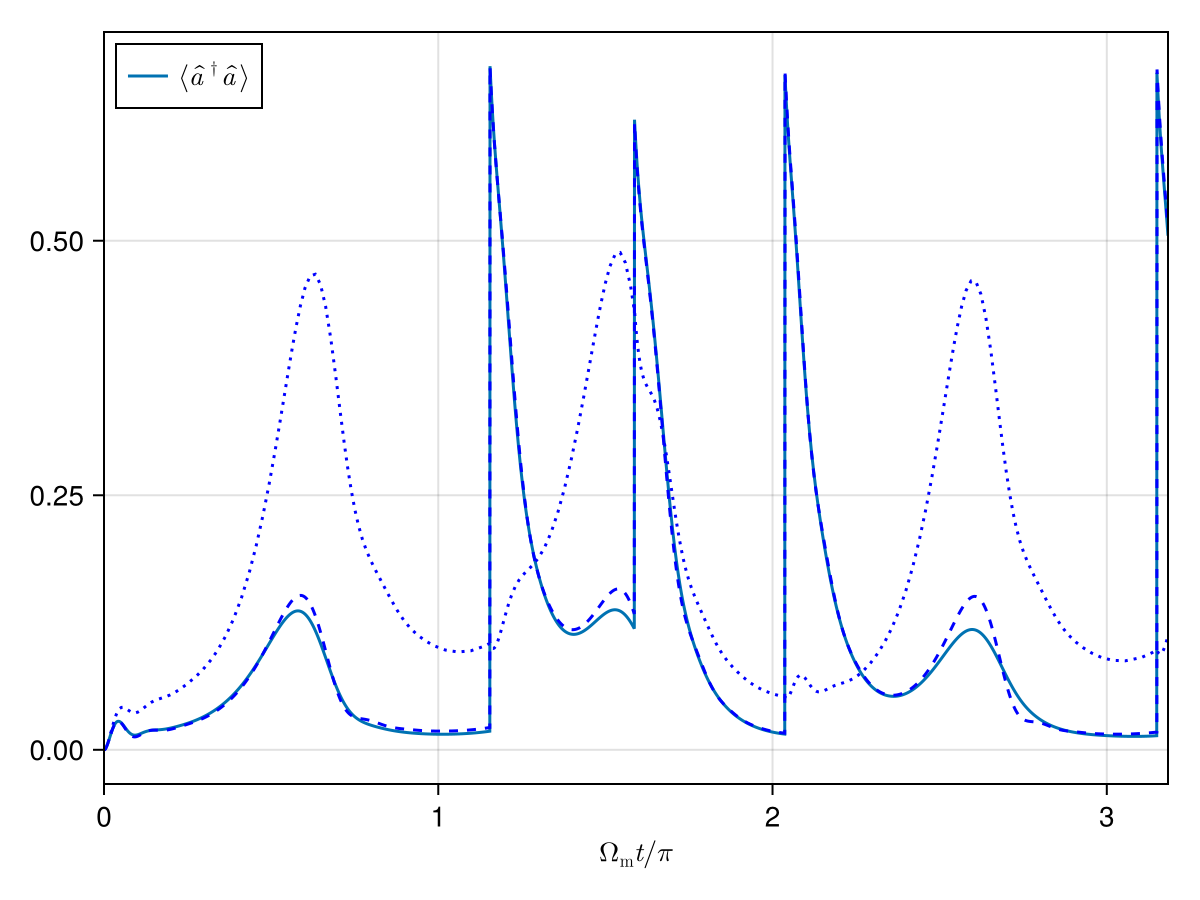

In [ ]:
# figures cavity - Fig. 13. panels (c) and (f)
F = Figure()
ax = Axis(F[1,1],xlabel = L"\Omega_\text{m}t/\pi")
lines!(ax,tplot/pi, exp_nc_master_st,label = L"\langle\hat{a}^\dagger\hat{a}\rangle")
lines!(ax,ftplot_st/pi, fnc_st, color = :blue, linestyle = :dash)
lines!(ax,tar2/pi, getindex.(utot,1), color = :blue, linestyle = :dot)

axislegend(position = :lt)
xlims!(ax,0,tsim/pi)

FH. As a first simplification, we go into a rotating frame

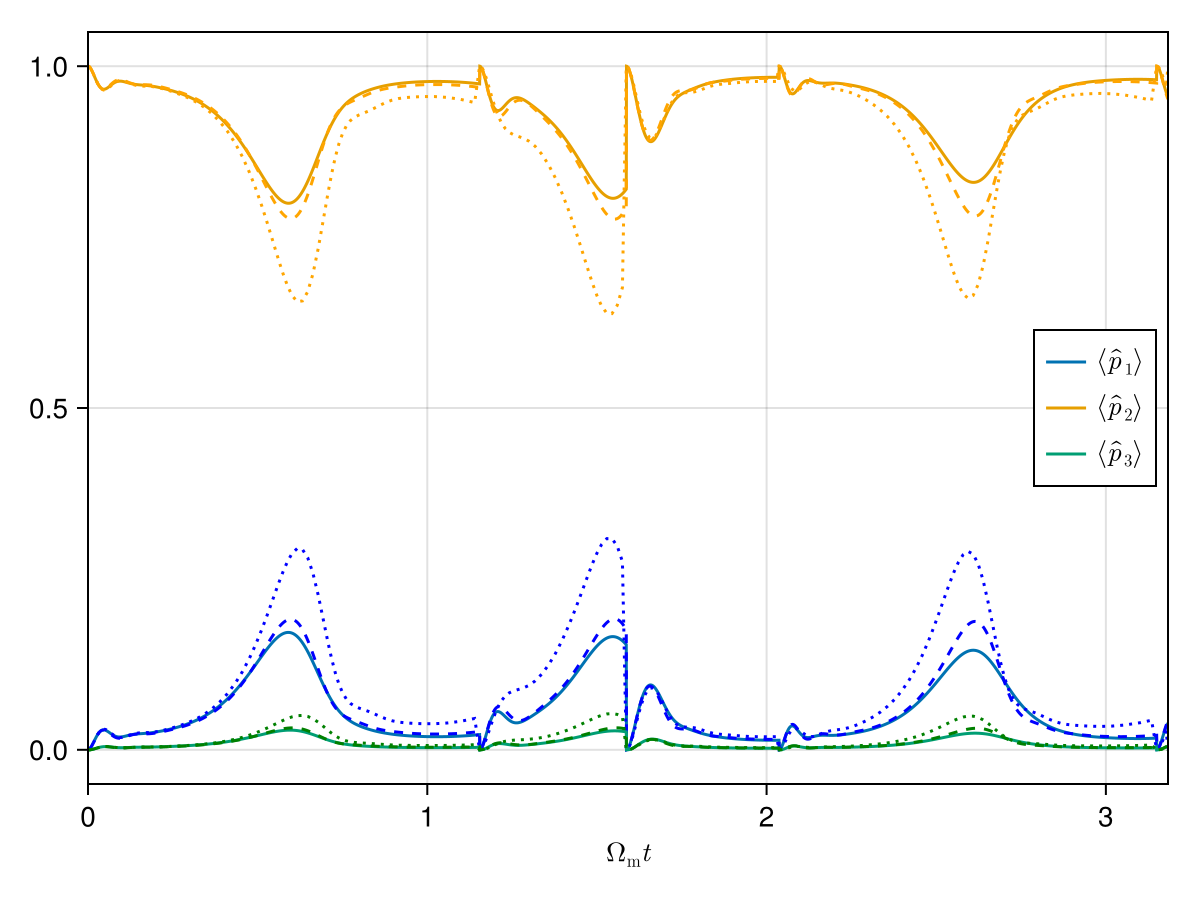

In [ ]:
# figures atom - Fig. 13 panels (b) and (e)
F = Figure()
ax = Axis(F[1,1],xlabel = L"\Omega_\text{m}t")

lines!(ax,tplot/pi, exp_p1_master_st, label = L"\langle\hat{p}_1\rangle")
lines!(ax,ftplot_st/pi, fp1_st, color = :blue, linestyle = :dash)
lines!(ax,tar2/pi, getindex.(utot,4), color = :blue, linestyle = :dot)

lines!(ax,tplot/pi, exp_p2_master_st, label = L"\langle\hat{p}_2\rangle")
lines!(ax,ftplot_st/pi, fp2_st, color = :orange, linestyle = :dash)
lines!(ax,tar2/pi, getindex.(utot,5),color = :orange, linestyle = :dot)

lines!(ax,tplot/pi, exp_p3_master_st, label = L"\langle\hat{p}_3\rangle")
lines!(ax,ftplot_st/pi, fp3_st, color = :green, linestyle = :dash)
lines!(ax,tar2/pi, -getindex.(utot,4).-getindex.(utot,5).+1, color = :green, linestyle = :dot)


axislegend(position = :rc)
xlims!(ax,0,tsim/pi)

F